In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set up plotting style
plt.style.use('fivethirtyeight')

In [2]:
# Define file paths
RAW_DATA_PATH = "../data/raw/btc_data_full.csv"

# Create the data/raw/ directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

# --- Download Data ---
# We only download if the file doesn't already exist
if not os.path.exists(RAW_DATA_PATH):
    print("Downloading data from Yahoo Finance...")
    # Download all data from 2023-11-01 to today (2025-11-01)
    data = yf.download("BTC-USD", 
                       start="2023-11-01", 
                       end="2025-11-02") # yf is exclusive of end date, so add 1 day
    
    # Save to our raw data folder
    data.to_csv(RAW_DATA_PATH)
    print(f"Data saved to {RAW_DATA_PATH}")
else:
    print(f"Data file already exists at {RAW_DATA_PATH}. Loading from file.")

C:\Users\DELL\AppData\Local\Temp\ipykernel_16496\2294766130.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD",
[*********************100%***********************]  1 of 1 completed

Data saved to ../data/raw/btc_data_full.csv


In [38]:
# Load the raw data from our CSV
df = pd.read_csv("../data/raw/btc_data_full.csv")

# Inspect the first 5 rows
print(df.head())

# Inspect the data types
print(df.info())

        Price           Close            High             Low            Open  \
0      Ticker         BTC-USD         BTC-USD         BTC-USD         BTC-USD   
1        Date             NaN             NaN             NaN             NaN   
2  2023-11-01  35437.25390625   35527.9296875  34170.69140625   34657.2734375   
3  2023-11-02   34938.2421875     35919.84375  34401.57421875    35441.578125   
4  2023-11-03  34732.32421875  34942.47265625  34133.44140625  34942.47265625   

        Volume  
0      BTC-USD  
1          NaN  
2  22446272005  
3  20998158544  
4  17158456701  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   734 non-null    object
 1   Close   733 non-null    object
 2   High    733 non-null    object
 3   Low     733 non-null    object
 4   Open    733 non-null    object
 5   Volume  733 non-null    object
dtypes: object(6)
m

In [39]:
df=df.drop([0,1])
df=df.rename(columns={'Price':'Date'})
print(df.head(5))

         Date           Close            High             Low            Open  \
2  2023-11-01  35437.25390625   35527.9296875  34170.69140625   34657.2734375   
3  2023-11-02   34938.2421875     35919.84375  34401.57421875    35441.578125   
4  2023-11-03  34732.32421875  34942.47265625  34133.44140625  34942.47265625   
5  2023-11-04   35082.1953125     35256.03125  34616.69140625  34736.32421875   
6  2023-11-05  35049.35546875  35340.33984375   34594.2421875  35090.01171875   

        Volume  
2  22446272005  
3  20998158544  
4  17158456701  
5   9561294264  
6  12412743996  


In [40]:
df=df.reset_index(drop=True)
print(df.head(5))
print(df.info())

         Date           Close            High             Low            Open  \
0  2023-11-01  35437.25390625   35527.9296875  34170.69140625   34657.2734375   
1  2023-11-02   34938.2421875     35919.84375  34401.57421875    35441.578125   
2  2023-11-03  34732.32421875  34942.47265625  34133.44140625  34942.47265625   
3  2023-11-04   35082.1953125     35256.03125  34616.69140625  34736.32421875   
4  2023-11-05  35049.35546875  35340.33984375   34594.2421875  35090.01171875   

        Volume  
0  22446272005  
1  20998158544  
2  17158456701  
3   9561294264  
4  12412743996  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    732 non-null    object
 1   Close   732 non-null    object
 2   High    732 non-null    object
 3   Low     732 non-null    object
 4   Open    732 non-null    object
 5   Volume  732 non-null    object
dtypes: object(6)
m

In [41]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the index
df.set_index('Date', inplace=True)

# We are only interested in the 'Close' price for this project
# Let's create a new, simpler DataFrame
df_close = df[['Close']].copy()

print("Data after setting DatetimeIndex:")
print(df_close.head())
print(df_close.info())

Data after setting DatetimeIndex:
                     Close
Date                      
2023-11-01  35437.25390625
2023-11-02   34938.2421875
2023-11-03  34732.32421875
2023-11-04   35082.1953125
2023-11-05  35049.35546875
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 732 entries, 2023-11-01 to 2025-11-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   732 non-null    object
dtypes: object(1)
memory usage: 11.4+ KB
None


In [42]:
# Converting Close column type into numerical
df_close['Close']=pd.to_numeric(df_close['Close'])
print(df_close.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 732 entries, 2023-11-01 to 2025-11-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   732 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB
None


In [43]:
# Split the Data (Train & Test)
# Define our cutoff date for backtesting
cutoff_date = '2025-09-30'

# Create training set: All data up to and including the cutoff date
train_data = df_close.loc[df_close.index <= cutoff_date]

# Create test set: All data after the cutoff date
test_data = df_close.loc[df_close.index > cutoff_date]

# --- Verification ---
print("--- Data Split Verification ---")
print(f"Total data points: {len(df_close)}")
print(f"Training data points: {len(train_data)}")
print(f"Test data points: {len(test_data)}")
print("-" * 30)
print(f"Training data ends: {train_data.index.max()}")
print(f"Test data starts: {test_data.index.min()}")

--- Data Split Verification ---
Total data points: 732
Training data points: 700
Test data points: 32
------------------------------
Training data ends: 2025-09-30 00:00:00
Test data starts: 2025-10-01 00:00:00


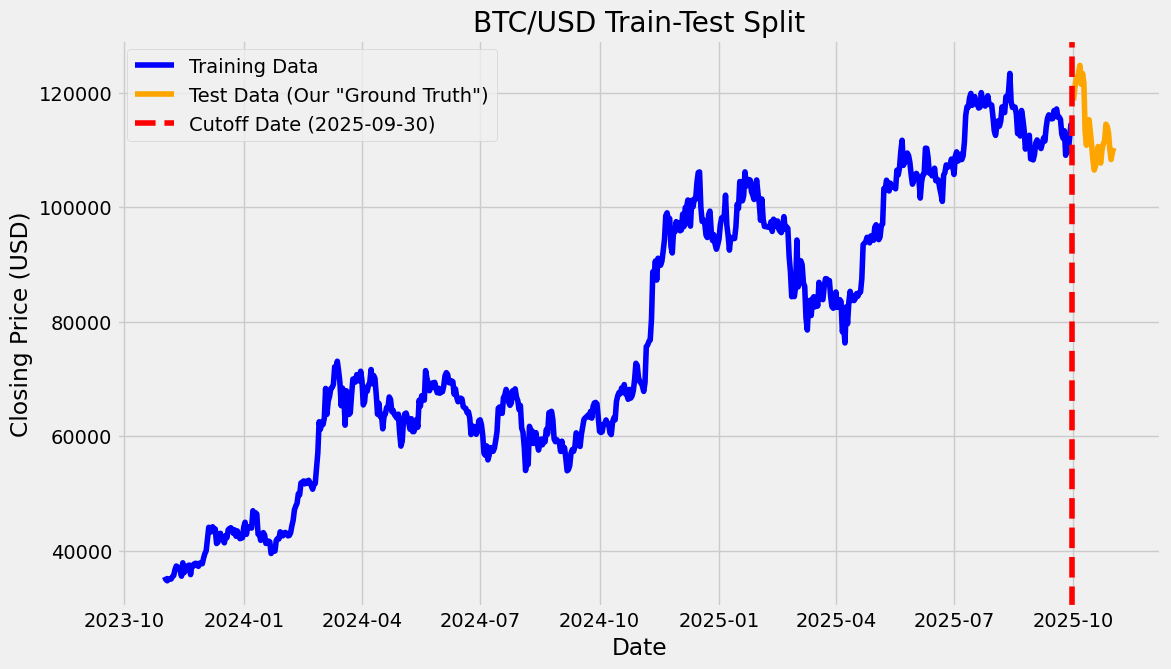

In [44]:
# Plot the train/test split
plt.figure(figsize=(12, 7))

# Plot training data in blue
plt.plot(train_data['Close'], label='Training Data', color='blue')

# Plot test data in orange
plt.plot(test_data['Close'], label='Test Data (Our "Ground Truth")', color='orange')

# Add a vertical line at the split
plt.axvline(pd.to_datetime(cutoff_date), 
            color='red', 
            linestyle='--', 
            label='Cutoff Date (2025-09-30)')

plt.title('BTC/USD Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

In [45]:
# We will now focus on the training data only 
# Checking for Stationarity (Augmented Dickey-Fuller Test)
from statsmodels.tsa.stattools import adfuller

In [46]:
# --- Run the ADF Test on our TRAINING data ---
# We only test on the training data to avoid any look-ahead bias
print("Running Augmented Dickey-Fuller Test on Raw 'Close' Data...")
adf_result = adfuller(train_data['Close'])

# --- Print a clear, readable summary ---
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value}')

if adf_result[1] > 0.05:
    print("\nResult: Fail to reject the null hypothesis (H0).")
    print("The data is NON-STATIONARY.")
else:
    print("\nResult: Reject the null hypothesis (H0).")
    print("The data is STATIONARY.")

Running Augmented Dickey-Fuller Test on Raw 'Close' Data...
ADF Statistic: -1.174422447796664
p-value: 0.6845006371338453
Critical Values:
	1%: -3.439753311961436
	5%: -2.8656896390914217
	10%: -2.568979777013325

Result: Fail to reject the null hypothesis (H0).
The data is NON-STATIONARY.


Original data points: 700, Differenced data points: 699

--- First 5 rows of differenced data ---
Date
2023-11-02   -499.011719
2023-11-03   -205.917969
2023-11-04    349.871094
2023-11-05    -32.839844
2023-11-06    -11.984375
Name: Close, dtype: float64


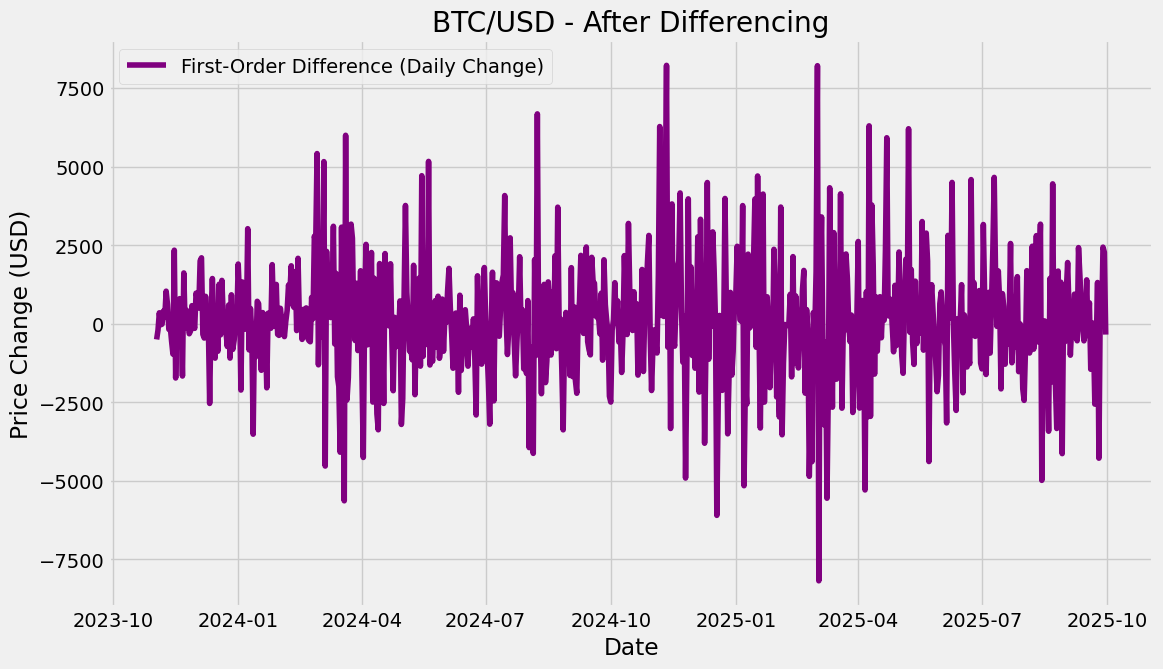


Running ADF Test on Differenced Data...
ADF Statistic: -28.85213436403276
p-value: 0.0

Result: Reject the null hypothesis (H0).
The differenced data is NOW STATIONARY.


In [47]:
# let's remove the trend 
# instead of modeling the price, we will model the change in price from one day to the next. Y'_t = Y_t - Y_(t-1)
# then reapply te ADF test to verify
# --- Apply first-order differencing to the training data ---
# This calculates the difference from one day to the next
train_data_diff = train_data['Close'].diff()

# The first row will be NaN (Not a Number) since it has no previous value
# We must drop it before testing
train_data_diff = train_data_diff.dropna()

print(f"Original data points: {len(train_data)}, Differenced data points: {len(train_data_diff)}")
print("\n--- First 5 rows of differenced data ---")
print(train_data_diff.head())

# --- Plot the differenced data ---
plt.figure(figsize=(12, 7))
plt.plot(train_data_diff, label='First-Order Difference (Daily Change)', color='purple')
plt.title('BTC/USD - After Differencing')
plt.xlabel('Date')
plt.ylabel('Price Change (USD)')
plt.legend()
plt.show()

# --- Re-run the ADF Test on the DIFFERENCED data ---
print("\nRunning ADF Test on Differenced Data...")
adf_result_diff = adfuller(train_data_diff)

print(f'ADF Statistic: {adf_result_diff[0]}')
print(f'p-value: {adf_result_diff[1]}')

if adf_result_diff[1] > 0.05:
    print("\nResult: Fail to reject the null hypothesis (H0).")
    print("The differenced data is STILL non-stationary.")
else:
    print("\nResult: Reject the null hypothesis (H0).")
    print("The differenced data is NOW STATIONARY.")

#### NEXT STEPS :
- Let's find the other parameters for our **ARIMA(p, d, q)** model:

     **d** (Integrated):  d = 1 because we elminated the trend.

     **p** (AutoRegressive): How many past values (lags) influence the current value?

     **q** (Moving Average): How many past forecast errors (lags) influence the current value?

- To find p and q, we'll use two more plots:

     **ACF (Autocorrelation Function)**: Helps us find the q value.

    **PACF (Partial Autocorrelation Function)**: Helps us find the p value.

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

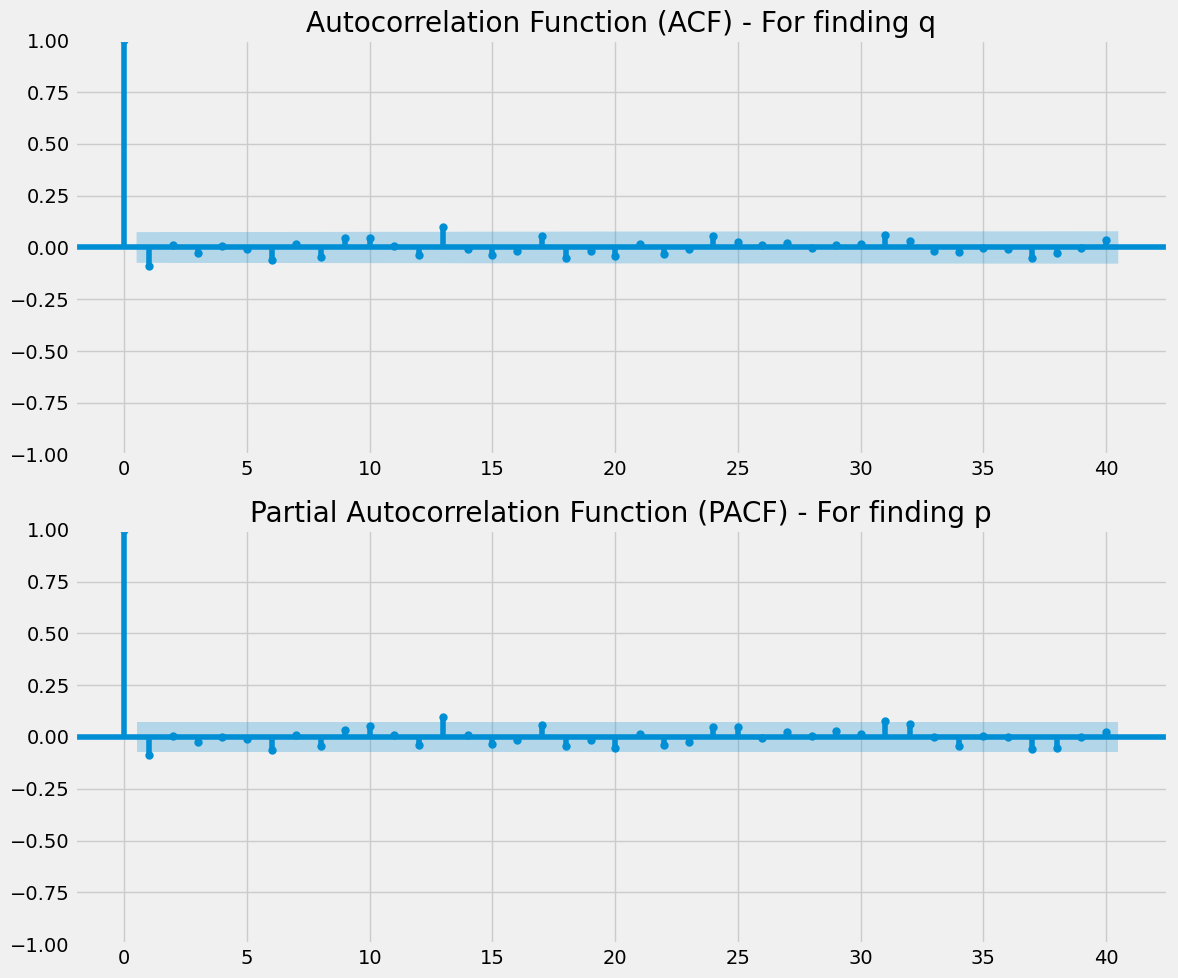

In [49]:
# --- Plot ACF and PACF ---
# We use our stationary (differenced) data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot the ACF
# The 'lags' parameter specifies how many lags to show. 40 is a good start.
plot_acf(train_data_diff, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) - For finding q')

# Plot the PACF
plot_pacf(train_data_diff, lags=40, ax=ax2, method='ywm') # 'ywm' is a reliable method
ax2.set_title('Partial Autocorrelation Function (PACF) - For finding p')

plt.tight_layout()
plt.show()

#### READING THE PLOTS
Looking at the ACF plot (top), there's a strong, significant spike at lag 1, and then it immediately "cuts off." All the other lags fall inside the blue shaded area, meaning they aren't significant.

For the PACF plot (bottom), It shows a very similar pattern: a strong significant spike at lag 1, and then it also cuts off. Lag 2 is well inside the shaded area, meaning it's not statistically significant.

 - So, the evidence from our plots points to:
    - **p = 1** (from the PACF cutoff)
    - **q = 1** (from the ACF cutoff)
#### OUR FIRST MODEL TO TEST WILL BE :  ARIMA(1, 1, 1).

In [50]:
# --- Saving our processed data ---
PROCESSED_PATH = "../data/processed/"

# Creating the directory if it doesn't exist
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Saving the train and test sets
train_data.to_csv(PROCESSED_PATH + "train_data.csv")
test_data.to_csv(PROCESSED_PATH + "test_data.csv")

print(f"Training and test data saved to {PROCESSED_PATH}")

Training and test data saved to ../data/processed/
